Import the required libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Upload the dataset

In [4]:
from google.colab import files

uploaded = files.upload()

Saving car data.csv to car data (1).csv


Read the dataset

In [5]:
data = pd.read_csv("car data.csv")

data.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [6]:
print("Number of rows:", data.shape[0])
print("Number of columns:", data.shape[1])

Number of rows: 301
Number of columns: 9


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [8]:
data.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


Check for missing values

In [9]:
data.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Driven_kms,0
Fuel_Type,0
Selling_type,0
Transmission,0
Owner,0


Check duplicate records

In [10]:
print("Duplicate rows:", data.duplicated().sum())

Duplicate rows: 2


In [11]:
data = data.drop_duplicates()

print("Rows after removing duplicates:", len(data))

Rows after removing duplicates: 299


Understand the categorical column

dataset contains columns such as:

Fuel_Type

Selling_type

Transmission

In [12]:
print("Fuel types:")
print(data["Fuel_Type"].value_counts())

print("\nSelling types:")
print(data["Selling_type"].value_counts())

print("\nTransmission types:")
print(data["Transmission"].value_counts())

Fuel types:
Fuel_Type
Petrol    239
Diesel     58
CNG         2
Name: count, dtype: int64

Selling types:
Selling_type
Dealer        193
Individual    106
Name: count, dtype: int64

Transmission types:
Transmission
Manual       260
Automatic     39
Name: count, dtype: int64


Feature Engineering

The Year column tells us when the car was manufactured.

Instead of directly using the year, we can calculate the age of the car.

In [13]:
current_year = 2026

data["Car_Age"] = current_year - data["Year"]

data[["Year", "Car_Age"]].head()

,Year,Car_Age
0,2014,12
1,2013,13
2,2017,9
3,2011,15
4,2014,12


Remove unnecessary columns

Car_Name contains the name of the car.

For this simple regression model, we won't use it because it has many different text values.

We can also remove the original Year column because we have created Car_Age.

In [14]:
data = data.drop(["Car_Name", "Year"], axis=1)

data.head()

,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


Convert categorical data into numbers

Machine learning models work with numerical values.

We'll convert:

Petrol/Diesel/CNG
Dealer/Individual
Manual/Automatic

into numerical values.

In [15]:
data = pd.get_dummies(data, columns=["Fuel_Type", "Selling_type", "Transmission"], drop_first=True)

data.head()

,Selling_Price,Present_Price,Driven_kms,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,12,False,True,False,True
1,4.75,9.54,43000,0,13,True,False,False,True
2,7.25,9.85,6900,0,9,False,True,False,True
3,2.85,4.15,5200,0,15,False,True,False,True
4,4.60,6.87,42450,0,12,True,False,False,True


Check the final dataset

In [16]:
print(data.columns)

Index(['Selling_Price', 'Present_Price', 'Driven_kms', 'Owner', 'Car_Age',
       'Fuel_Type_Diesel', 'Fuel_Type_Petrol', 'Selling_type_Individual',
       'Transmission_Manual'],
      dtype='object')


In [17]:
X = data.drop("Selling_Price", axis=1)
y = data["Selling_Price"]

print("Features:")
print(X.columns)

print("\nTarget:")
print(y.name)

Features:
Index(['Present_Price', 'Driven_kms', 'Owner', 'Car_Age', 'Fuel_Type_Diesel',
       'Fuel_Type_Petrol', 'Selling_type_Individual', 'Transmission_Manual'],
      dtype='object')

Target:
Selling_Price


Split the dataset

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (239, 8)
Testing data: (60, 8)


Train the Linear Regression model

In [19]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


Make predictions

In [20]:
predictions = model.predict(X_test)

print("First 10 predicted prices:")
print(predictions[:10])

First 10 predicted prices:
[ 7.50049519  7.791134    1.36525272  7.00895369 11.16501084  4.53381705
  8.49154086  1.69915065  8.82263182 -0.96326043]


Evaluate the model

In [21]:
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)

Mean Absolute Error: 1.472545750817864
Mean Squared Error: 6.373125106260703
Root Mean Squared Error: 2.5245049230018752
R2 Score: 0.7527233824220487


Compare actual and predicted prices

In [22]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": predictions
})

comparison.head(10)

,Actual Price,Predicted Price
0,8.99,7.500495
1,8.35,7.791134
2,0.45,1.365253
3,7.45,7.008954
4,5.25,11.165011
5,5.25,4.533817
6,5.85,8.491541
7,1.15,1.699151
8,9.25,8.822632
9,0.38,-0.963260


Plot actual vs predicted prices

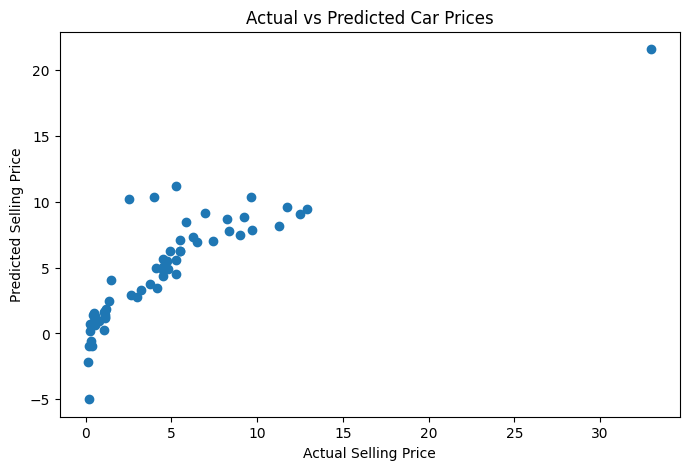

In [23]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Car Prices")

plt.show()

Check which features influence the prediction

We can look at the model coefficients.

In [24]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

feature_importance = feature_importance.sort_values(
    by="Coefficient",
    ascending=False
)

feature_importance

,Feature,Coefficient
4,Fuel_Type_Diesel,2.142391
5,Fuel_Type_Petrol,0.692516
2,Owner,0.640144
0,Present_Price,0.437119
1,Driven_kms,-0.000011
3,Car_Age,-0.330031
6,Selling_type_Individual,-1.302291
7,Transmission_Manual,-1.573425


Visualize the feature coefficients

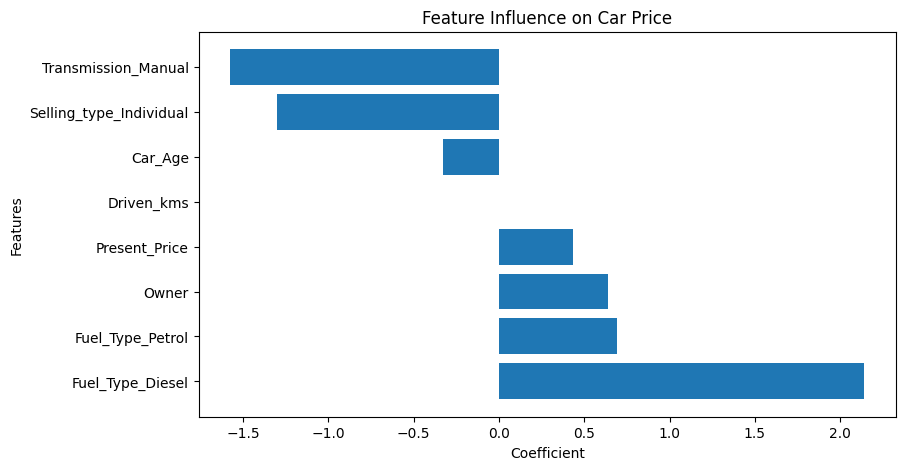

In [25]:
plt.figure(figsize=(9, 5))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Coefficient"]
)

plt.xlabel("Coefficient")
plt.ylabel("Features")
plt.title("Feature Influence on Car Price")

plt.show()

Test the model with a new car

Now let's actually use the trained model to predict the price of a car.

For example, we'll create a sample car.

In [26]:
new_car = pd.DataFrame({
    "Present_Price": [8.5],
    "Driven_kms": [40000],
    "Owner": [0],
    "Car_Age": [5],
    "Fuel_Type_Diesel": [0],
    "Fuel_Type_Petrol": [1],
    "Selling_type_Individual": [1],
    "Transmission_Manual": [1]
})

predicted_price = model.predict(new_car)

print("Predicted selling price:", round(predicted_price[0], 2), "lakhs")

Predicted selling price: 6.08 lakhs


let's Create a simple prediction function

In [27]:
def predict_car_price(present_price, driven_kms, owner,
                      car_age, fuel_type, selling_type, transmission):

    fuel_diesel = 1 if fuel_type.lower() == "diesel" else 0
    fuel_petrol = 1 if fuel_type.lower() == "petrol" else 0

    selling_individual = 1 if selling_type.lower() == "individual" else 0
    transmission_manual = 1 if transmission.lower() == "manual" else 0

    car = pd.DataFrame({
        "Present_Price": [present_price],
        "Driven_kms": [driven_kms],
        "Owner": [owner],
        "Car_Age": [car_age],
        "Fuel_Type_Diesel": [fuel_diesel],
        "Fuel_Type_Petrol": [fuel_petrol],
        "Selling_type_Individual": [selling_individual],
        "Transmission_Manual": [transmission_manual]
    })

    price = model.predict(car)

    return price[0]

Use the function

In [28]:
price = predict_car_price(
    present_price=8.5,
    driven_kms=40000,
    owner=0,
    car_age=5,
    fuel_type="Petrol",
    selling_type="Individual",
    transmission="Manual"
)

print("Estimated car price:", round(price, 2), "lakhs")

Estimated car price: 6.08 lakhs


Final conclusion

In this project, a Linear Regression model was developed to predict the
selling price of used cars.

The dataset was cleaned and preprocessed before training the model.
Categorical features such as fuel type, selling type and transmission
were converted into numerical values.

A new feature called Car_Age was also created from the manufacturing year.

The model was evaluated using MAE, MSE, RMSE and R2 Score. The results
show that machine learning can be used to estimate used car prices
based on features such as present price, kilometers driven, ownership,
car age, fuel type and transmission.

This project demonstrates a practical application of machine learning
in automobile price prediction.